**Build a Semantic Search Ready NLP Pipeline from Raw Text Data**

In [1]:
#Install All Dependencies
!pip install datasets nltk spacy scikit-learn gensim matplotlib seaborn wordcloud umap-learn -q
!python -m spacy download en_core_web_sm -q

import nltk
for pkg in ['punkt','punkt_tab','stopwords','wordnet','omw-1.4','averaged_perceptron_tagger']:
    nltk.download(pkg, quiet=True)

print('All dependencies installed and NLTK data downloaded.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 21.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 26.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All dependencies installed and NLTK data downloaded.


In [60]:
#Imports
import re, string, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# HuggingFace
from datasets import load_dataset

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist

# SpaCy
import spacy

# Scikit-learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Gensim
from gensim.models import Word2Vec, FastText
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [61]:
#Load Dataset from HuggingFace
print('Loading yelp_review_full from HuggingFace...')
dataset = load_dataset('yelp_review_full', split='train[:5000]')
df = pd.DataFrame(dataset)
df.columns = ['label', 'text']
df['label'] = df['label'] + 1   # Map 0-4 -> 1-5 stars

print(f'Loaded {len(df):,} reviews')
print(f'\nStar distribution:')
print(df['label'].value_counts().sort_index().to_string())
df.head(3)

Loading yelp_review_full from HuggingFace...
Loaded 5,000 reviews

Star distribution:
label
1     883
2    1126
3    1119
4     978
5     894


,label,text
0,5,dr. goldberg offers everything i look for in a...
1,2,"Unfortunately, the frustration of being Dr. Go..."
2,4,Been going to Dr. Goldberg for over 10 years. ...


In [62]:
#Text Cleaning

def clean_text(text: str) -> str:
    text = text.lower()

    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\bn([a-z]+)', r'\1', text)                    # fix newline artifacts
    text = re.sub(r'http\S+|www\.\S+|\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)

    # handle contractions
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)

    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['cleaned_text'] = df['text'].apply(clean_text)

#Before vs After
print('─' * 65)
print('ORIGINAL :', df['text'].iloc[0][:280])
print('\nCLEANED  :', df['cleaned_text'].iloc[0][:280])
print('─' * 65)

orig_len  = df['text'].str.len().mean()
clean_len = df['cleaned_text'].str.len().mean()
print(f'\nAvg length: {orig_len:.0f} chars → {clean_len:.0f} chars '
      f'({(1 - clean_len/orig_len)*100:.1f}% reduction)')

─────────────────────────────────────────────────────────────────
ORIGINAL : dr. goldberg offers everything i look for in a general practitioner.  he's nice and easy to talk to without being patronizing; he's always on time in seeing his patients; he's affiliated with a top-notch hospital (nyu) which my parents have explained to me is very important in ca

CLEANED  : dr goldberg offers everything i look for in a general practitioner he is ice and easy to talk to without being patronizing he is always on time in seeing his patients he is affiliated with a top otch hospital yu which my parents have explained to me is very important in case some
─────────────────────────────────────────────────────────────────

Avg length: 738 chars → 708 chars (4.1% reduction)


In [63]:
#Tokenization (NLTK word_tokenize)
df['tokens'] = df['cleaned_text'].str.split()

token_lengths = df['tokens'].apply(len)
unique_vocab  = set(t for toks in df['tokens'] for t in toks)

print('Token Statistics')
print(f'  Mean tokens per review : {token_lengths.mean():.1f}')
print(f'  Max  tokens per review : {token_lengths.max()}')
print(f'  Min  tokens per review : {token_lengths.min()}')
print(f'  Total tokens           : {token_lengths.sum():,}')
print(f'  Unique vocabulary size : {len(unique_vocab):,}')
print('\nSample tokens (first review):', df['tokens'].iloc[0][:20])

Token Statistics
  Mean tokens per review : 139.2
  Max  tokens per review : 971
  Min  tokens per review : 0
  Total tokens           : 695,762
  Unique vocabulary size : 19,364

Sample tokens (first review): ['dr', 'goldberg', 'offers', 'everything', 'i', 'look', 'for', 'in', 'a', 'general', 'practitioner', 'he', 'is', 'ice', 'and', 'easy', 'to', 'talk', 'to', 'without']


In [64]:
#Stopword Removal

STOP_WORDS = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

df['tokens_no_sw'] = df['tokens'].apply(remove_stopwords)

before = df['tokens'].apply(len).sum()
after  = df['tokens_no_sw'].apply(len).sum()
print(f'Tokens before stopword removal : {before:,}')
print(f'Tokens after  stopword removal : {after:,}')
print(f'Tokens removed                 : {before - after:,}  ({(before-after)/before*100:.1f}%)')
print(f'\nStopword list size: {len(STOP_WORDS)}')
print('Sample stopwords:', sorted(list(STOP_WORDS))[:15])

Tokens before stopword removal : 695,762
Tokens after  stopword removal : 326,404
Tokens removed                 : 369,358  (53.1%)

Stopword list size: 198
Sample stopwords: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]


In [65]:

# LEMMATIZATION (NLTK vs SPACY)

from nltk.stem import WordNetLemmatizer
import spacy


#NLTK LEMMATIZATION


wnl = WordNetLemmatizer()

def lemmatize_nltk(tokens):
    return [wnl.lemmatize(t) for t in tokens]

df['lemmas_nltk'] = df['tokens_no_sw'].apply(lemmatize_nltk)
print('NLTK lemmatization done.')


#SPACY LEMMATIZATION

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def lemmatize_spacy(tokens):

    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc if not token.is_punct and len(token.text) > 2]

df['lemmas_spacy'] = df['tokens_no_sw'].apply(lemmatize_spacy)
print('SpaCy lemmatization done (FULL dataset).')



df['lemmas']     = df['lemmas_spacy']
df['lemma_text'] = df['lemmas'].apply(' '.join)



#SIDE-BY-SIDE COMPARISON


print('\nToken vs Lemma comparison (first review, 12 tokens):')
print(f'{"Token":<20} {"NLTK Lemma":<20} {"SpaCy Lemma":<20}')
print('─' * 65)

for tok, lem_nltk, lem_spacy in zip(
    df['tokens_no_sw'].iloc[0][:12],
    df['lemmas_nltk'].iloc[0][:12],
    df['lemmas_spacy'].iloc[0][:12]
):
    print(f'{tok:<20} {lem_nltk:<20} {lem_spacy:<20}')


changed_nltk = sum(
    1 for toks, lems in zip(df['tokens_no_sw'], df['lemmas_nltk'])
    for t, l in zip(toks, lems) if t != l
)

changed_spacy = sum(
    1 for toks, lems in zip(df['tokens_no_sw'], df['lemmas_spacy'])
    for t, l in zip(toks, lems) if t != l
)

total = df['tokens_no_sw'].apply(len).sum()

print('\nLemmatization Impact:')
print(f'  NLTK  changed: {changed_nltk:,} / {total:,} ({changed_nltk/total*100:.1f}%)')
print(f'  SpaCy changed: {changed_spacy:,} / {total:,} ({changed_spacy/total*100:.1f}%)')


#QUALITY CHECK


from collections import Counter

vocab = Counter(t for toks in df['lemmas'] for t in toks)

print('\nTop 20 words after SpaCy lemmatization:')
for word, freq in vocab.most_common(20):
    print(f'{word:<15} {freq}')


#SAMPLE OUTPUT


print('\nFinal sample lemmas:')
print(df['lemmas'].iloc[0][:20])

print('\nFinal vocabulary size:',
      len(set(t for toks in df['lemmas'] for t in toks)))

NLTK lemmatization done.
SpaCy lemmatization done (FULL dataset).

Token vs Lemma comparison (first review, 12 tokens):
Token                NLTK Lemma           SpaCy Lemma         
─────────────────────────────────────────────────────────────────
goldberg             goldberg             goldberg            
offers               offer                offer               
everything           everything           everything          
look                 look                 look                
general              general              general             
practitioner         practitioner         practitioner        
ice                  ice                  ice                 
easy                 easy                 easy                
talk                 talk                 talk                
without              without              without             
patronizing          patronizing          patronize           
always               always               always          

In [66]:
def remove_noise_tokens(tokens):
    return [t for t in tokens if not t.startswith('n')]

df['lemmas'] = df['lemmas'].apply(remove_noise_tokens)

In [68]:
import re
from collections import Counter

# token cleaning
def clean_final_tokens(tokens):
    return [
        t for t in tokens
        if re.match(r'^[a-z]+$', t)   # only alphabets
        and len(t) > 2                # remove short garbage
    ]

df['lemmas'] = df['lemmas'].apply(clean_final_tokens)

# remove rare words (noise reduction)
word_counts = Counter(t for sent in df['lemmas'] for t in sent)

df['lemmas'] = df['lemmas'].apply(
    lambda toks: [t for t in toks if word_counts[t] >= 10]
)


In [69]:
nlp = spacy.load("en_core_web_sm")

def remove_proper_nouns(tokens):
    doc = nlp(" ".join(tokens))
    return [t.text for t in doc if t.pos_ != "PROPN"]

df['lemmas'] = df['lemmas'].apply(remove_proper_nouns)

In [70]:
from gensim.models.phrases import Phrases, Phraser

phrases = Phrases(df['lemmas'], min_count=5, threshold=10)
bigram = Phraser(phrases)

df['lemmas'] = df['lemmas'].apply(lambda x: bigram[x])

In [71]:
#Vocabulary Creation

all_lemmas = [lemma for lemmas in df['lemmas'] for lemma in lemmas]
freq_dist  = FreqDist(all_lemmas)

MIN_FREQ   = 5
vocabulary = {word: idx for idx, (word, freq)
              in enumerate(freq_dist.most_common()) if freq >= MIN_FREQ}

print(f'Total unique lemmas        : {len(freq_dist):,}')
print(f'Vocabulary (freq >= {MIN_FREQ})   : {len(vocabulary):,}')

Total unique lemmas        : 3,874
Vocabulary (freq >= 5)   : 3,747


In [72]:
#Bag of Words & TF-IDF Vectors

#Bag of Words
bow_vec = CountVectorizer(max_features=5000, min_df=5)
X_bow   = bow_vec.fit_transform(df['lemma_text'])
print(f'BoW   matrix shape   : {X_bow.shape}')
print(f'BoW   non-zeros      : {X_bow.nnz:,}')
print(f'BoW   sparsity       : {(1-X_bow.nnz/(X_bow.shape[0]*X_bow.shape[1]))*100:.2f}%')

#TF-IDF with bigrams
tfidf_vec = TfidfVectorizer(max_features=5000, min_df=5, ngram_range=(1, 2))
X_tfidf   = tfidf_vec.fit_transform(df['lemma_text'])
print(f'\nTFIDF matrix shape   : {X_tfidf.shape}')
print(f'TFIDF non-zeros      : {X_tfidf.nnz:,}')
print(f'TFIDF sparsity       : {(1-X_tfidf.nnz/(X_tfidf.shape[0]*X_tfidf.shape[1]))*100:.2f}%')


BoW   matrix shape   : (5000, 4585)
BoW   non-zeros      : 246,455
BoW   sparsity       : 98.92%

TFIDF matrix shape   : (5000, 5000)
TFIDF non-zeros      : 275,631
TFIDF sparsity       : 98.90%


In [73]:
# Word Embeddings: Word2Vec & FastText

from umap import UMAP

sentences = df['lemmas'].tolist()

#Word2Vec Skip-gram
print('Training Word2Vec (Skip-gram, dim=200, epochs=20)...')
w2v_model = Word2Vec(
    sentences, vector_size=200, window=7,
    min_count=10, workers=4, sg=1, epochs=20
)
print(f'Word2Vec vocab size : {len(w2v_model.wv):,}')

#FastText
print('Training FastText (dim=200, epochs=20)...')
ft_model = FastText(
    sentences, vector_size=200, window=7,
    min_count=10, workers=4, epochs=20
)
print(f'FastText vocab size : {len(ft_model.wv):,}')

#Similar words demo
print('\n── Word2Vec Similarity Demo ────────────────────────')
for seed in ['food', 'service', 'place', 'delicious', 'rude']:
    try:
        sim = w2v_model.wv.most_similar(seed, topn=5)
        print(f'\nTop-5 similar to "{seed}":')
        for word, score in sim:
            print(f'  {word:<22} {score:.4f}')
    except KeyError:
        print(f'  "{seed}" not in vocabulary')

Training Word2Vec (Skip-gram, dim=200, epochs=20)...
Word2Vec vocab size : 3,225
Training FastText (dim=200, epochs=20)...
FastText vocab size : 3,225

── Word2Vec Similarity Demo ────────────────────────

Top-5 similar to "food":
  overrate               0.5005
  friendly_attentive     0.4916
  indian_food            0.4854
  bloody_mary            0.4762
  superb                 0.4671

Top-5 similar to "service":
  friendly_attentive     0.5234
  wait_staff             0.4853
  poor_service           0.4775
  attentive              0.4570
  incompetent            0.4548

Top-5 similar to "place":
  tourist                0.4762
  downtown_area          0.4703
  treasure               0.4682
  overrate               0.4676
  mom_pop                0.4658

Top-5 similar to "delicious":
  dipping_sauce          0.4574
  main_entree            0.4380
  quite_tasty            0.4337
  delish                 0.4279
  melt_mouth             0.4156

Top-5 similar to "rude":
  unprofessional

In [74]:
# Sentence Embeddings with Doc2Vec

from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import numpy as np


tagged_docs = [
    TaggedDocument(words=row['lemmas'], tags=[i])
    for i, row in df.iterrows()
]

print(f'Total documents: {len(tagged_docs):,}')


# Build & Train Doc2Vec (PV-DM)

print('\nTraining Doc2Vec (PV-DM)...')

doc2vec_dm = Doc2Vec(
    vector_size=150,
    window=8,
    min_count=10,
    workers=4,
    dm=1,                 # PV-DM
    epochs=30
)

doc2vec_dm.build_vocab(tagged_docs)

print(f'Vocabulary size: {len(doc2vec_dm.wv):,}')

doc2vec_dm.train(
    tagged_docs,
    total_examples=doc2vec_dm.corpus_count,
    epochs=doc2vec_dm.epochs
)


# Train Doc2Vec (PV-DBOW)

print('\nTraining Doc2Vec (PV-DBOW)...')

doc2vec_dbow = Doc2Vec(
    vector_size=150,
    window=8,
    min_count=10,
    workers=4,
    dm=0,                 # PV-DBOW
    epochs=30
)

doc2vec_dbow.build_vocab(tagged_docs)

doc2vec_dbow.train(
    tagged_docs,
    total_examples=doc2vec_dbow.corpus_count,
    epochs=doc2vec_dbow.epochs
)

# Combine embeddings


sentence_vectors = np.hstack([
    np.array([doc2vec_dm.dv[i] for i in range(len(df))]),
    np.array([doc2vec_dbow.dv[i] for i in range(len(df))])
])

print(f'\nFinal embedding matrix: {sentence_vectors.shape}')

Total documents: 5,000

Training Doc2Vec (PV-DM)...
Vocabulary size: 3,225

Training Doc2Vec (PV-DBOW)...

Final embedding matrix: (5000, 300)


QUERY [0]  ⭐⭐⭐⭐⭐
dr. goldberg offers everything i look for in a general practitioner.  he's nice and easy to talk to without being patronizing; he's always on time in seeing his patients; he's affiliated with a top-notch hospital (nyu) w...

── Top-3 Similar Reviews (Word2Vec) ───────────────
  ⭐  sim=0.8930 | Interesting the reviews here are less than stellar already. I would normally not review a chain retail store, but the se...
  ⭐⭐⭐⭐⭐  sim=0.8843 | I first found the Newman Chiropractic Center about 2 years ago when one day, my lower back pain got so severe I could ba...
  ⭐  sim=0.8821 | Okay I wrote my previous review when I was mad at them for breaking into my apartment. I want to provide a more complete...

QUERY [100]  ⭐
My expectations for McDonalds are t rarely high. But for one to still fail so spectacularly...that takes something special!\nThe cashier took my friends's order, then promptly ignored me. I had to force myself in front o...

── Top-3 Similar Reviews (Word2Vec)

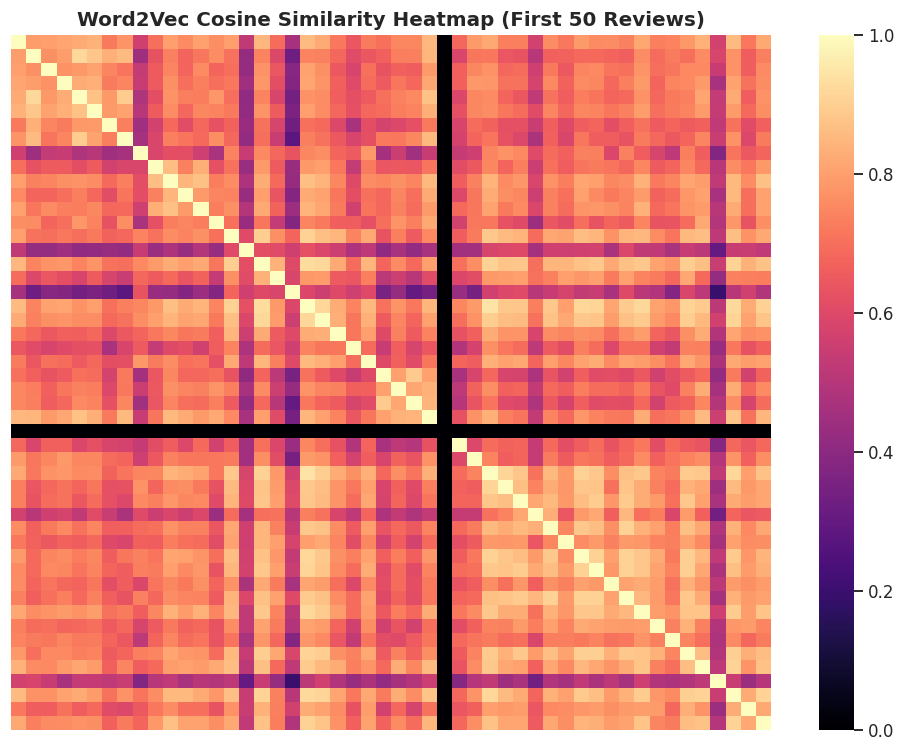

In [85]:
def find_similar_reviews(query_idx: int, top_k: int = 5):
    """
    Find top-k similar reviews using Word2Vec sentence embeddings.
    """

    # Build full matrix from W2V vectors
    all_vecs = np.vstack(df['w2v_sentence_vec'].values)

    # Query vector
    q = all_vecs[query_idx].reshape(1, -1)

    # Cosine similarity
    sims = cosine_similarity(q, all_vecs).flatten()

    # Exclude self and get top-k
    top_idx = sims.argsort()[::-1][1:top_k + 1]

    # Build result
    res = df.iloc[top_idx][['label', 'text']].copy()
    res['similarity'] = sims[top_idx].round(4)
    res['stars'] = res['label'].apply(lambda x: '⭐' * x)

    return res[['stars', 'similarity', 'text']]


for qidx in [0, 100, 500]:
    print('=' * 80)

    print(f'QUERY [{qidx}]  {"⭐" * df["label"].iloc[qidx]}')
    print(df['text'].iloc[qidx][:220] + '...')

    print('\n── Top-3 Similar Reviews (Word2Vec) ───────────────')

    results = find_similar_reviews(qidx, top_k=3)

    for _, row in results.iterrows():
        print(f'  {row["stars"]}  sim={row["similarity"]:.4f} | {row["text"][:120]}...')

    print()


# Cosine Similarity Heatmap

all_vecs = np.vstack(df['w2v_sentence_vec'].values)
sim_matrix = cosine_similarity(all_vecs[:50])

plt.figure(figsize=(9, 7))

sns.heatmap(
    sim_matrix,
    cmap='magma',
    xticklabels=False,
    yticklabels=False,
    linewidths=0
)

plt.title('Word2Vec Cosine Similarity Heatmap (First 50 Reviews)',
          fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

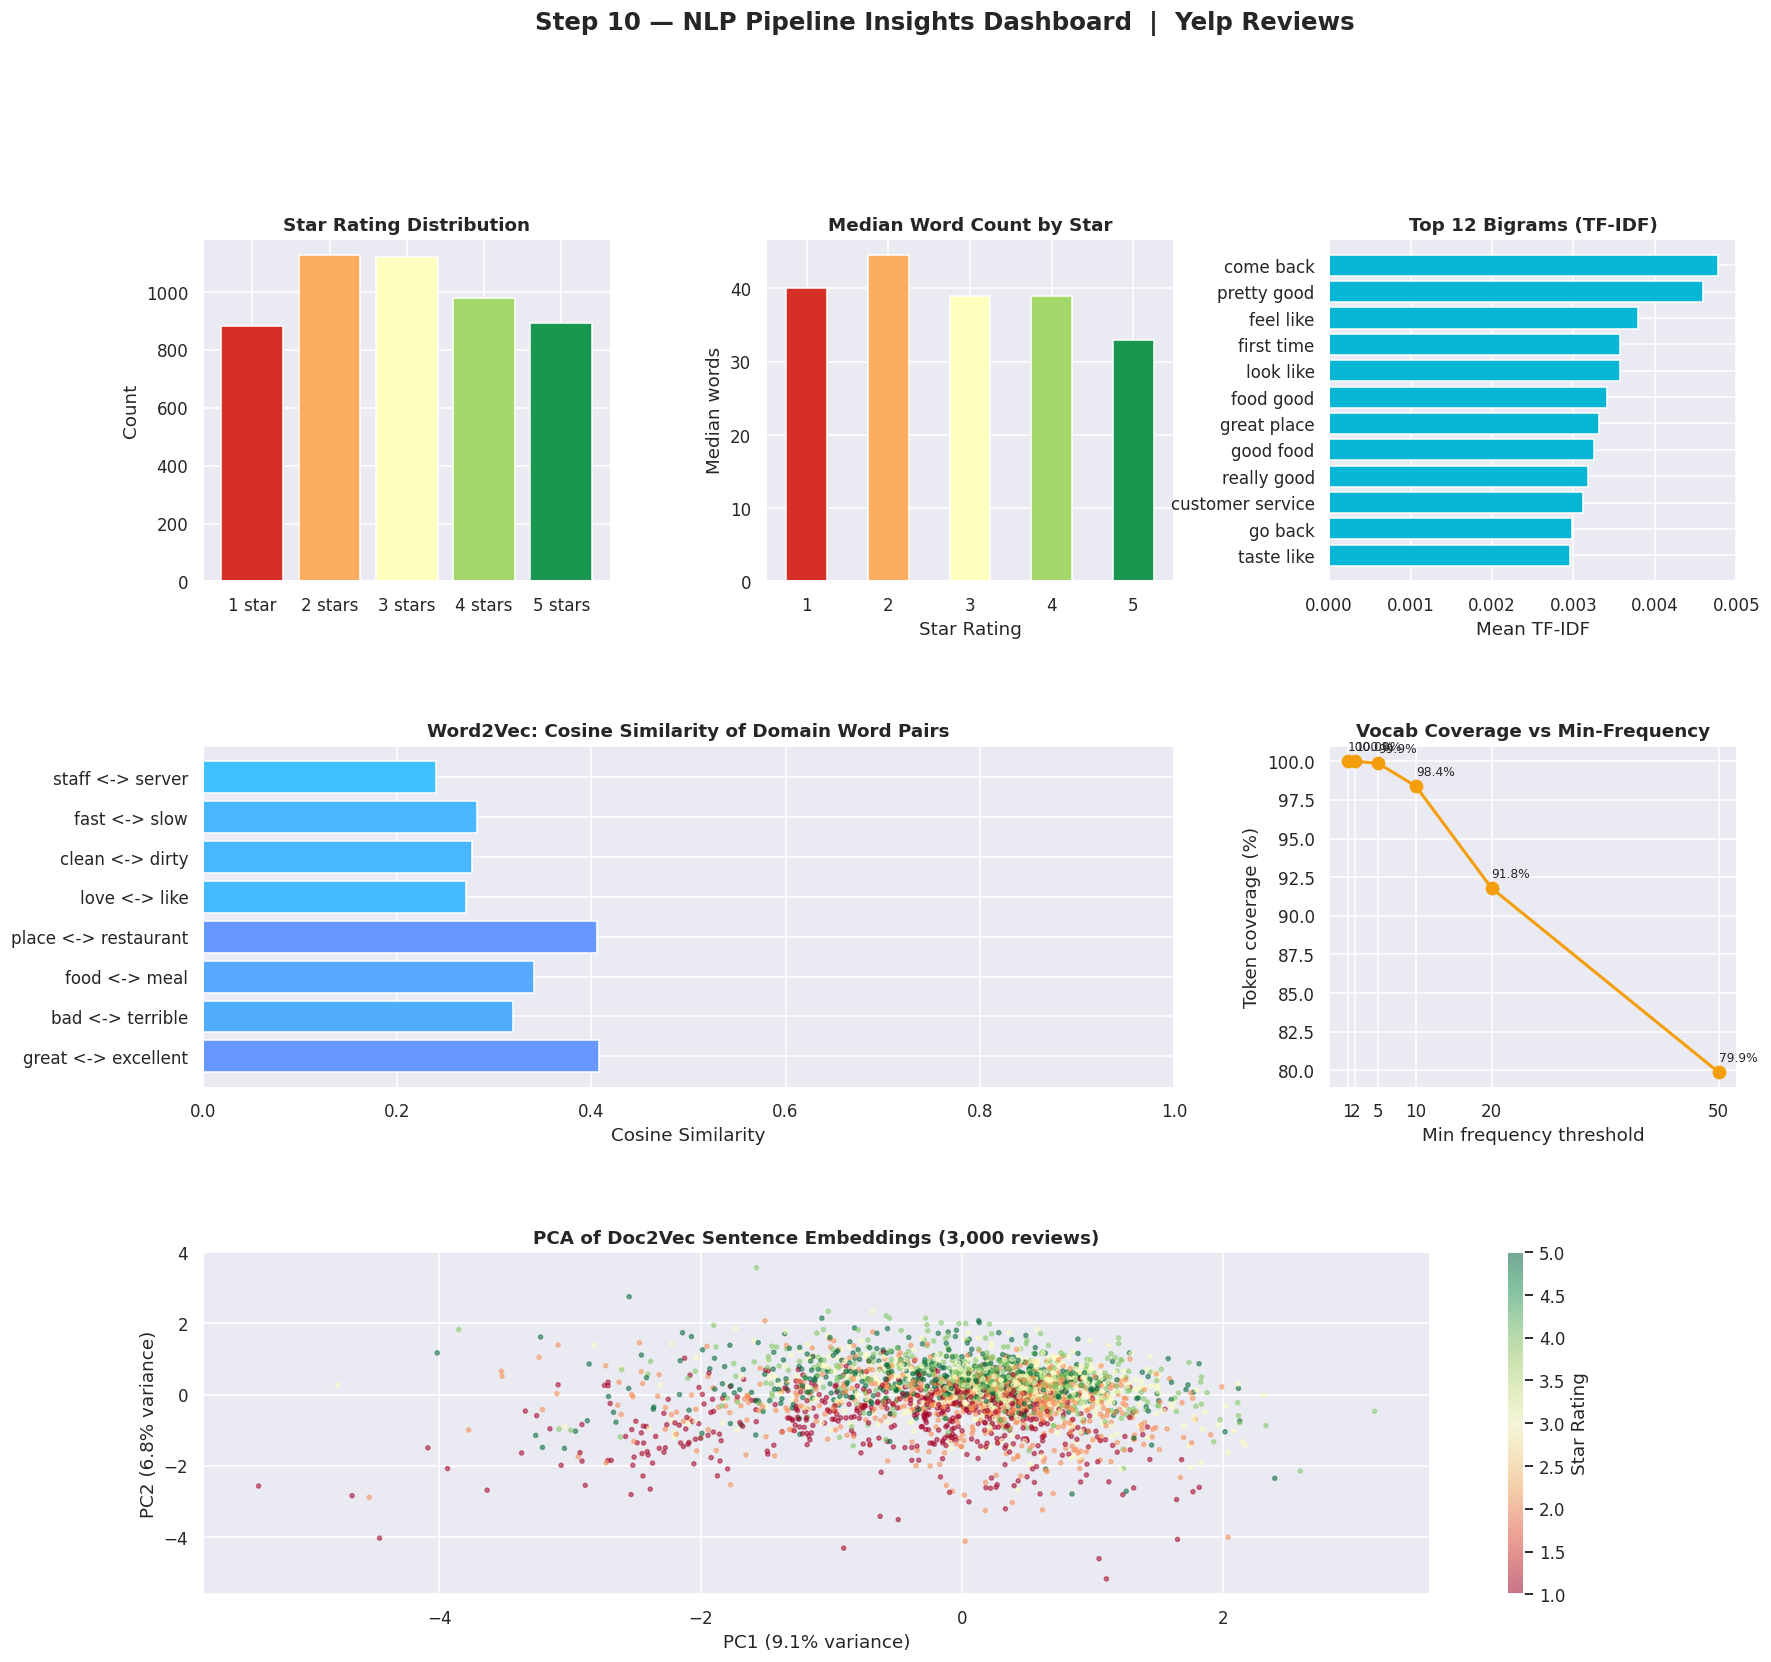

Dashboard saved as nlp_insights_dashboard.png


In [78]:
#Insights & Visualization Dashboard
df['word_count'] = df['lemmas'].apply(len)
colors5 = plt.cm.RdYlGn(np.linspace(0.1, 0.9, 5))

fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

# Panel 1 — Star rating distribution
ax1 = fig.add_subplot(gs[0, 0])
star_counts = df['label'].value_counts().sort_index()
ax1.bar([f"{i} star" if i == 1 else f"{i} stars" for i in range(1, 6)],star_counts.values,color=colors5)
ax1.set_title('Star Rating Distribution', fontweight='bold')
ax1.set_ylabel('Count')

# Panel 2 — Median word count by star
ax2 = fig.add_subplot(gs[0, 1])
df.groupby('label')['word_count'].median().plot(kind='bar', ax=ax2, color=colors5, rot=0)
ax2.set_title('Median Word Count by Star', fontweight='bold')
ax2.set_xlabel('Star Rating')
ax2.set_ylabel('Median words')

# Panel 3 — Top bigrams
ax3 = fig.add_subplot(gs[0, 2])
feat_names  = tfidf_vec.get_feature_names_out()
mean_scores = np.asarray(X_tfidf.mean(axis=0)).ravel()
bigram_list = [(feat_names[i], mean_scores[i])
               for i in range(len(feat_names)) if ' ' in feat_names[i]]
top_bg = sorted(bigram_list, key=lambda x: x[1], reverse=True)[:12]
bg_words, bg_vals = zip(*top_bg)
ax3.barh(bg_words[::-1], bg_vals[::-1], color='#06b6d4')
ax3.set_title('Top 12 Bigrams (TF-IDF)', fontweight='bold')
ax3.set_xlabel('Mean TF-IDF')

# Panel 4 — Word2Vec domain word pair similarity
ax4 = fig.add_subplot(gs[1, :2])
analogy_pairs = [('great','excellent'),('bad','terrible'),
                 ('food','meal'),('place','restaurant'),
                 ('love','like'),('clean','dirty'),
                 ('fast','slow'),('staff','server')]
valid_pairs = [(a,b) for a,b in analogy_pairs if a in w2v_model.wv and b in w2v_model.wv]
pair_sims   = [w2v_model.wv.similarity(a,b) for a,b in valid_pairs]
pair_labels = [f'{a} <-> {b}' for a,b in valid_pairs]
ax4.barh(pair_labels, pair_sims, color=plt.cm.cool(np.array(pair_sims)))
ax4.set_xlim(0, 1)
ax4.set_title('Word2Vec: Cosine Similarity of Domain Word Pairs', fontweight='bold')
ax4.set_xlabel('Cosine Similarity')

# Panel 5 — Vocabulary coverage vs min frequency
ax5 = fig.add_subplot(gs[1, 2])
thresholds = [1, 2, 5, 10, 20, 50]
coverage   = []
for t in thresholds:
    vt = {w for w, f in freq_dist.items() if f >= t}
    coverage.append(sum(1 for w in all_lemmas if w in vt) / len(all_lemmas) * 100)
ax5.plot(thresholds, coverage, 'o-', color='#f59e0b', lw=2, markersize=8)
ax5.set_title('Vocab Coverage vs Min-Frequency', fontweight='bold')
ax5.set_xlabel('Min frequency threshold')
ax5.set_ylabel('Token coverage (%)')
ax5.set_xticks(thresholds)
for t, c in zip(thresholds, coverage):
    ax5.annotate(f'{c:.1f}%', (t, c), textcoords='offset points', xytext=(0, 7), fontsize=8)

# Panel 6 — PCA of Doc2Vec sentence embeddings
ax6 = fig.add_subplot(gs[2, :])
pca      = PCA(n_components=2, random_state=42)
pca_vecs = pca.fit_transform(sentence_vectors[:3000])
sc2 = ax6.scatter(pca_vecs[:, 0], pca_vecs[:, 1],
                   c=df['label'][:3000], cmap='RdYlGn', s=7, alpha=0.5)
plt.colorbar(sc2, ax=ax6, label='Star Rating')
ax6.set_title('PCA of Doc2Vec Sentence Embeddings (3,000 reviews)',
              fontweight='bold', fontsize=12)
ax6.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax6.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')

fig.suptitle('Step 10 — NLP Pipeline Insights Dashboard  |  Yelp Reviews',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('nlp_insights_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

